In [1]:
from pathlib import Path
import re
from typing import Iterable

import os
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path(os.path.abspath('')).resolve().parents[2]
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import nvitk as nv
import numpy as np
# from nvitk.core import setup
# setup(globals())

from nvitk.core.logger import Logger
log = Logger()

In [17]:
def load_dixon_thorax_measurements(
    original_results_root: str | Path,
    newblock_results_root: str | Path,
    *,
    id_col: str = "pesa_id",
    batch_regex: str = r"^\d{6}_Week\d+$",
    thorax_prefixes: tuple[str, ...] = (
        "DIXON_LIVER_",
        "DIXON_PANCREAS_",
        "DIXON_KIDNEY_",
        "DIXON_T_PVM_",
        "DIXON_BN_",
    ),
) -> pd.DataFrame:
    """
    Load dixon summary files from two result roots and return one merged dataframe.
    Assumes each batch has:
      <root>/<batch>/res_measure_dixon/<batch>_SummaryCodebook.xlsx
    Returns columns:
      [batch, pesa_id, <thorax cols>_orig, <thorax cols>_new]
    """
    original_results_root = Path(original_results_root)
    newblock_results_root = Path(newblock_results_root)
    def _collect(root: Path, tag: str) -> pd.DataFrame:
        dfs = []
        for f in root.glob("*/res_measure_dixon/*_SummaryCodebook.xlsx"):
            batch = f.parent.parent.name  # <root>/<batch>/res_measure_dixon/...
            if not re.match(batch_regex, batch):
                continue
            df = pd.read_excel(f)
            if id_col not in df.columns:
                continue
            thorax_cols = [
                c for c in df.columns
                if any(c.startswith(p) for p in thorax_prefixes)
            ]
            keep = [id_col] + thorax_cols
            tmp = df[keep].copy()
            tmp["batch"] = batch
            tmp = tmp.rename(columns={c: f"{c}_{tag}" for c in thorax_cols})
            dfs.append(tmp)
        if not dfs:
            return pd.DataFrame(columns=["batch", id_col])
        out = pd.concat(dfs, ignore_index=True)
        out = out.drop_duplicates(subset=["batch", id_col], keep="last")
        return out
    df_orig = _collect(original_results_root, "orig")
    df_new = _collect(newblock_results_root, "new")
    merged = pd.merge(
        df_orig,
        df_new,
        on=["batch", id_col],
        how="inner",
        validate="one_to_one",
    ).sort_values(["batch", id_col]).reset_index(drop=True)
    return merged

    
def plot_thorax_correlations(
    df_merged: pd.DataFrame,
    *,
    cols: Iterable[str] | None = None,
    max_plots: int = None,
    figsize_per_plot: tuple[float, float] = (4.5, 4.0),
    plot_subject_names: bool = False,
) -> None:
    """
    Plot orig-vs-new scatter correlations for thorax measurement columns.
    If cols is None, auto-detects base columns present as both *_orig and *_new.
    """
    if cols is None:
        orig_cols = {c[:-5] for c in df_merged.columns if c.endswith("_orig")}
        new_cols = {c[:-4] for c in df_merged.columns if c.endswith("_new")}
        cols = sorted(orig_cols & new_cols)
    cols = list(cols)[:max_plots] if max_plots is not None else list(cols)
    if len(cols) == 0:
        raise ValueError("No matching *_orig/*_new columns found to plot.")
    n = len(cols)
    ncols = min(5, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize_per_plot[0] * ncols, figsize_per_plot[1] * nrows),
        squeeze=False,
    )
    for i, base in enumerate(cols):
        ax = axes[i // ncols][i % ncols]
        x = pd.to_numeric(df_merged[f"{base}_orig"], errors="coerce")
        y = pd.to_numeric(df_merged[f"{base}_new"], errors="coerce")
        m = x.notna() & y.notna()
        x, y = x[m], y[m]
        if len(x) == 0:
            ax.set_title(f"{base}\n(no paired data)")
            ax.axis("off")
            continue
        r = x.corr(y, method="pearson")
        ax.scatter(x, y, alpha=0.65, s=20)
        if plot_subject_names:
            for j, (x_, y_) in enumerate(zip(x, y)):
                ax.text(x_, y_, df_merged.iloc[j]["pesa_id"], fontsize=8)
        # identity line
        lo = np.nanmin([x.min(), y.min()])
        hi = np.nanmax([x.max(), y.max()])
        ax.plot([lo, hi], [lo, hi], "--", linewidth=1)
        ax.set_title(f"{base}\nr={r:.3f}  n={len(x)}")
        ax.set_xlabel("original THORAX")
        ax.set_ylabel("new THORAX block")
    # hide unused axes
    for j in range(n, nrows * ncols):
        axes[j // ncols][j % ncols].axis("off")
    fig.tight_layout()
    plt.show()

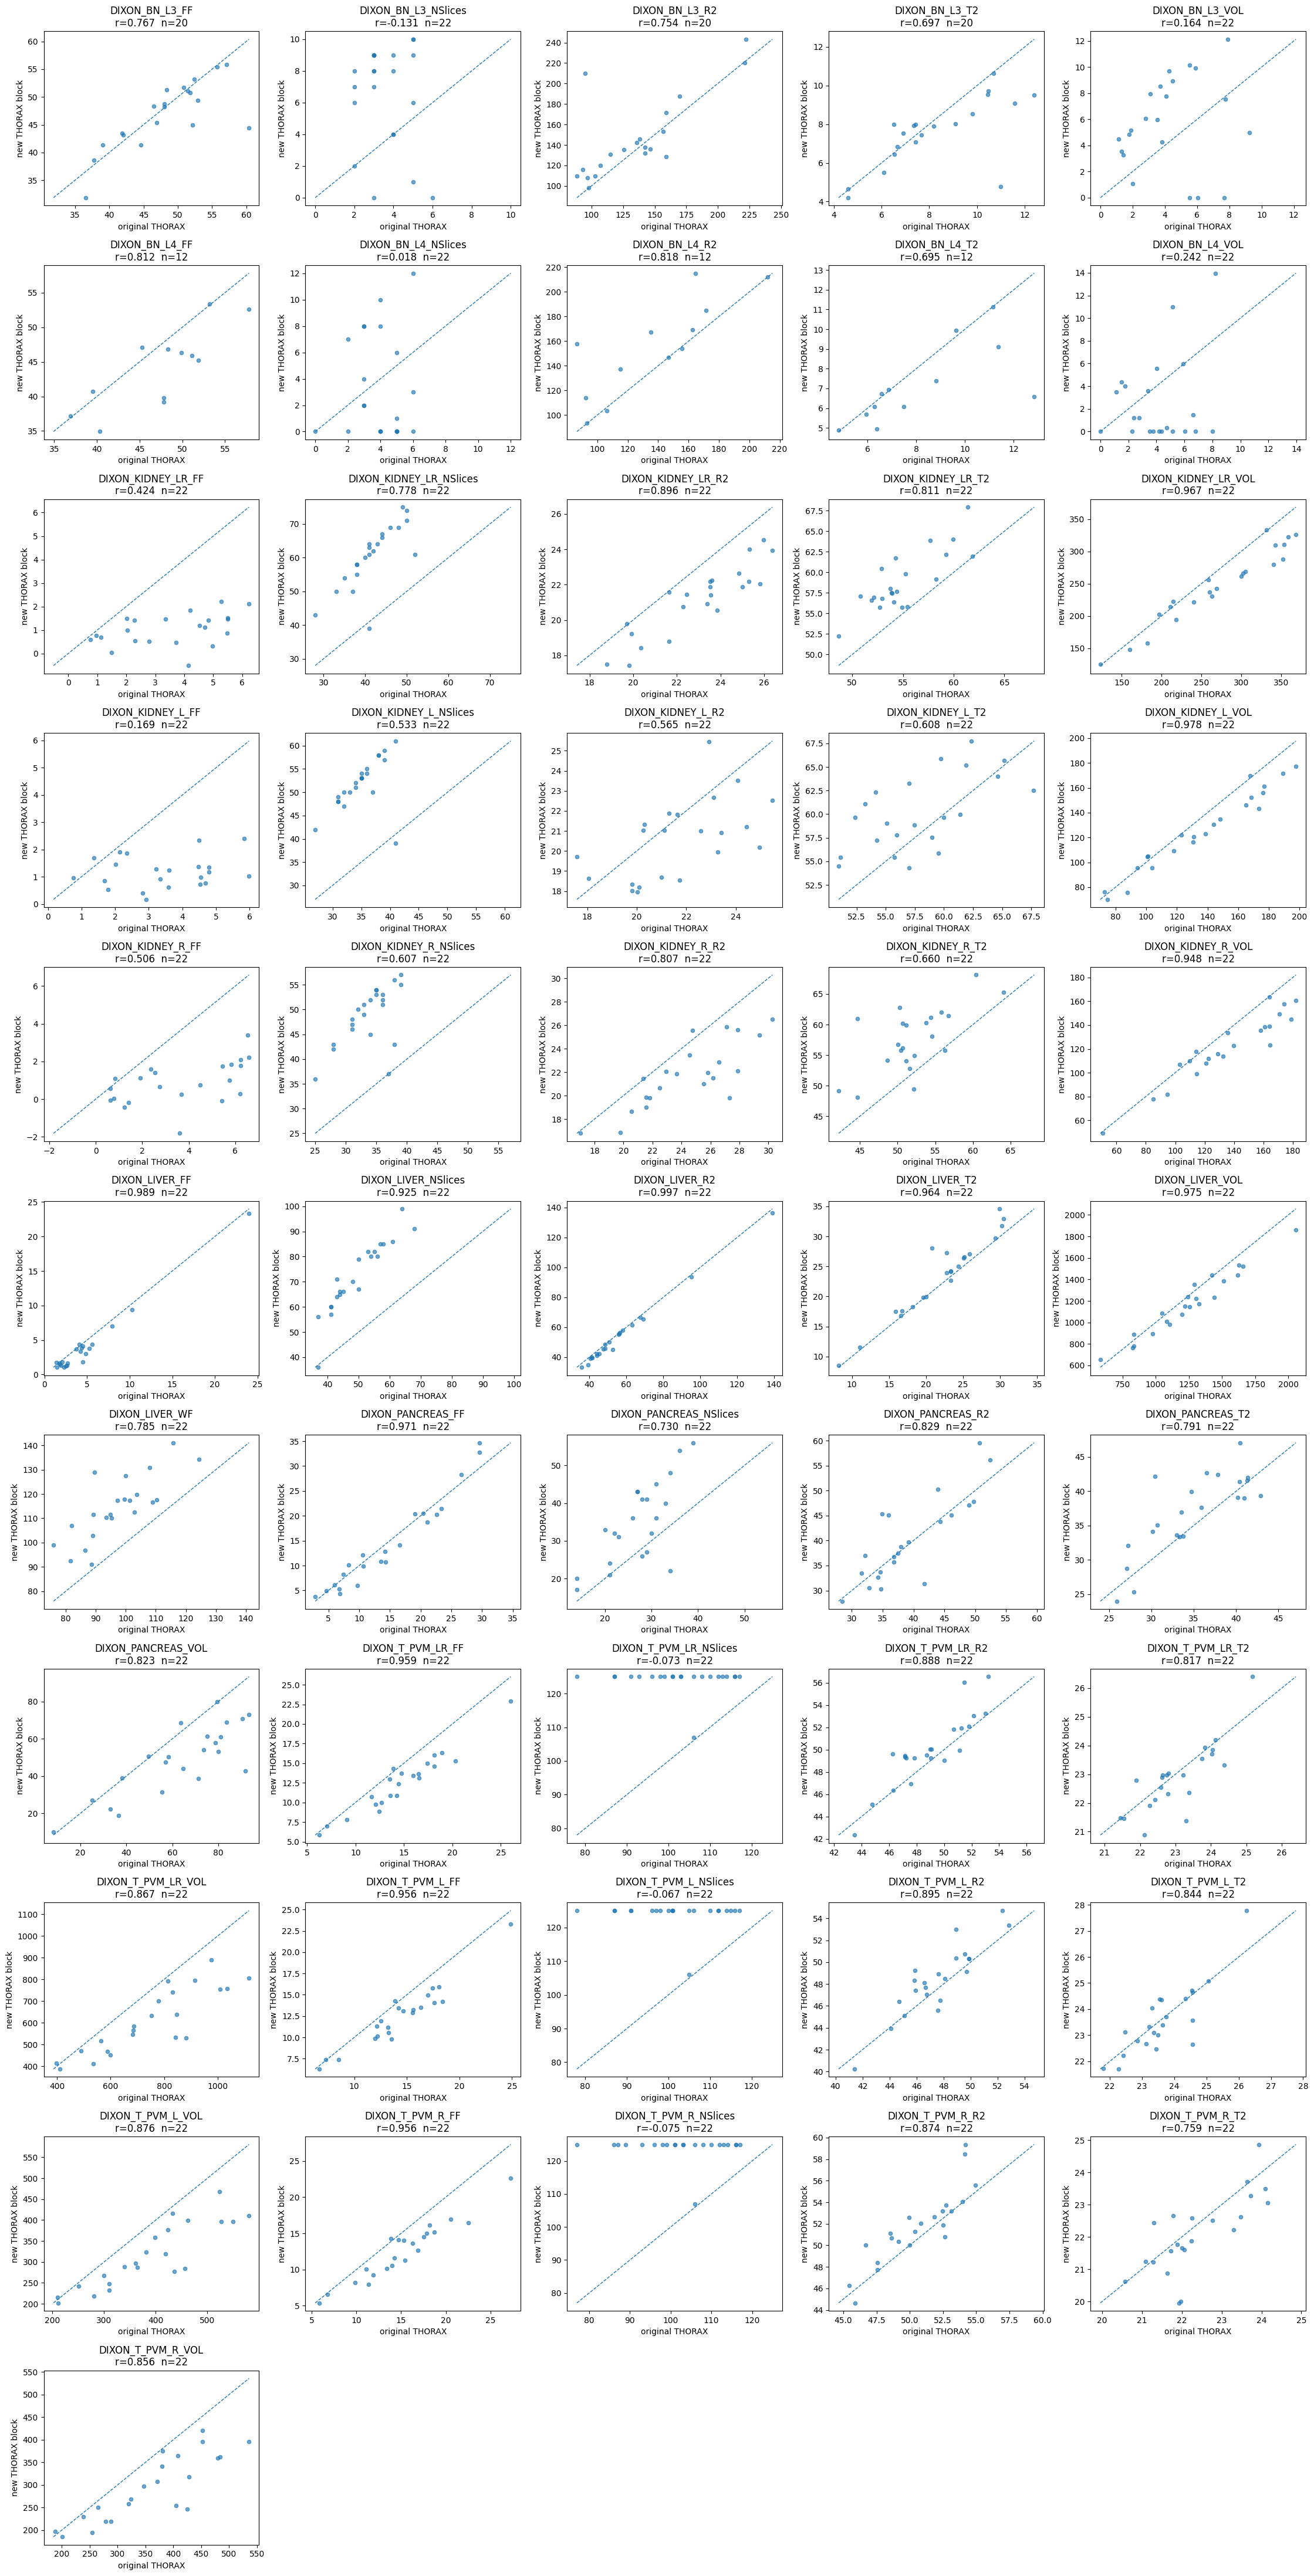

In [18]:
df_cmp = load_dixon_thorax_measurements(
    "/data3/BIOIT_IMAGE/PESA_Fat/DATA/Visit-5-DIXON_PET-CT/RESULTS/",
    "/data3/BIOIT_IMAGE/PESA_Fat/DATA/Visit-5-DIXON_PET-CT/RESULTS_DIXON500/",
)
plot_thorax_correlations(df_cmp)

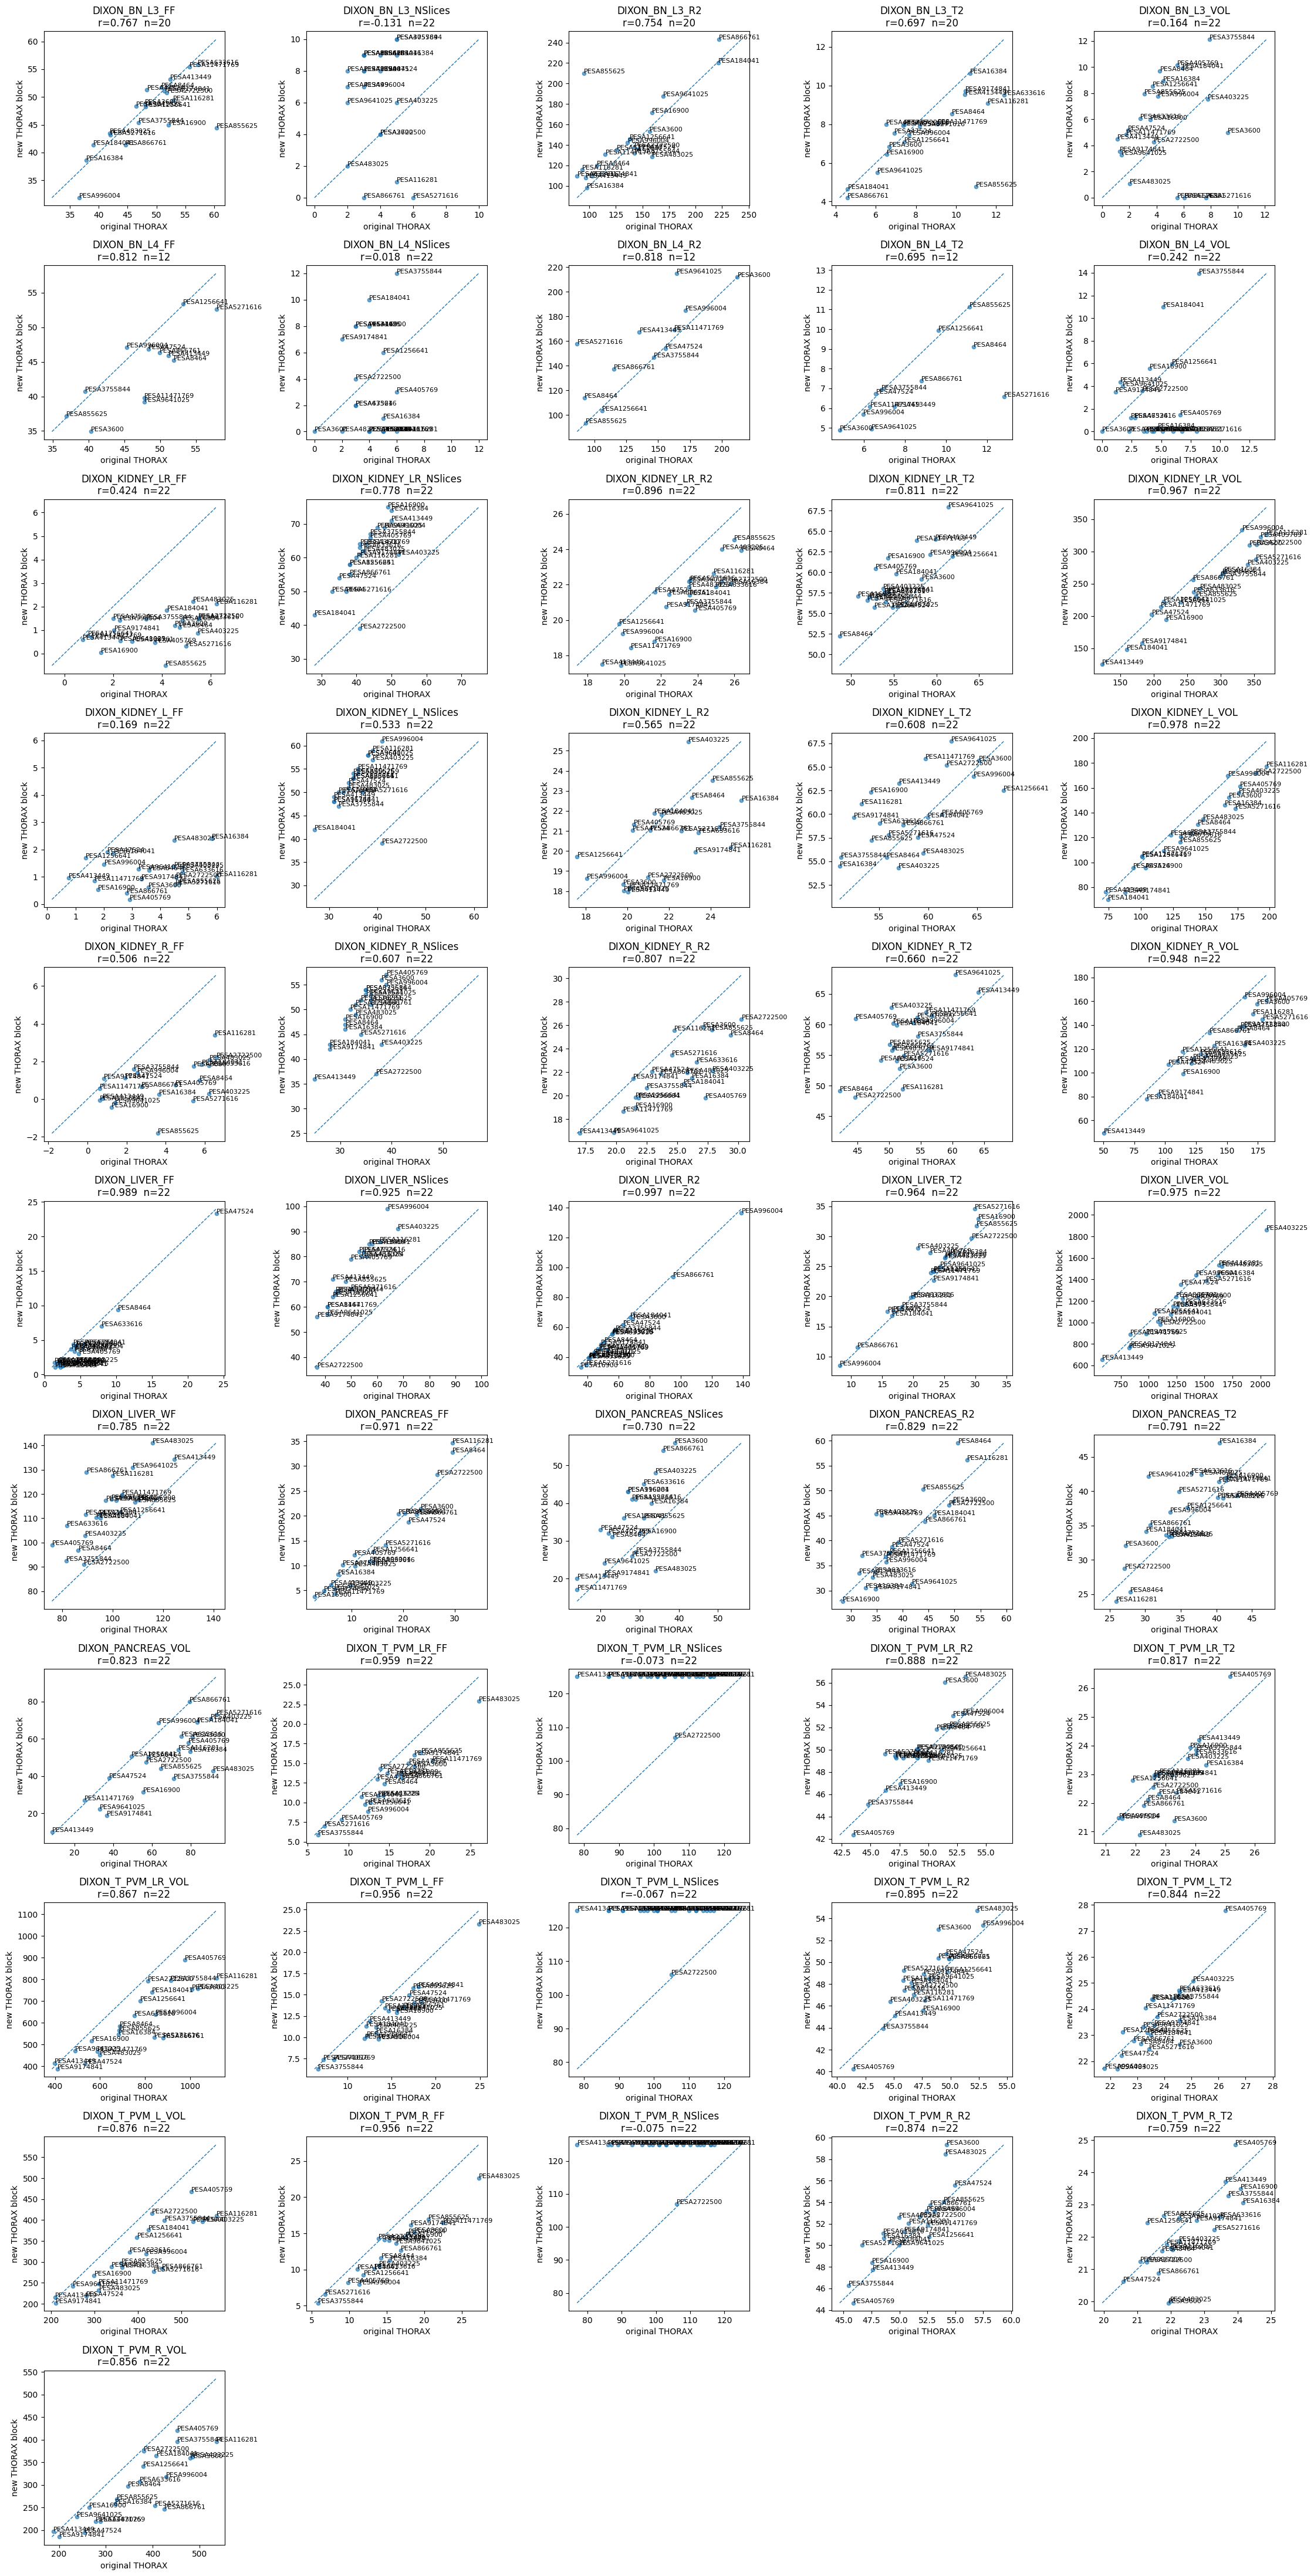

In [19]:
plot_thorax_correlations(df_cmp, plot_subject_names=True)